# Introduction to Machine Learning: Deep Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 2: Training and Regularizing Neural Networks

---

## Setup (do not edit)

In [1]:
import pathlib
from typing import Tuple, Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Suppress TensorFlow warnings for cleaner output
tf.get_logger().setLevel("ERROR")

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Fashion-MNIST class names for reference
CLASS_NAMES: List[str] = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

_TRAIN_PATH = pathlib.Path("fashion_mnist_train.csv")
_TEST_PATH = pathlib.Path("fashion_mnist_test.csv")

if not _TRAIN_PATH.exists() or not _TEST_PATH.exists():
    raise FileNotFoundError(
        "Fashion-MNIST CSV files are missing from the lab directory. "
        "Please run the download script or ask the TA for assistance."
    )

## 1. Load and Explore the Dataset *(10 points)*

The Fashion-MNIST dataset contains 70,000 grayscale images of 10 clothing categories.
Each image is 28×28 pixels, flattened into 784 features.

Write a function `load_data()` that:
1. Reads the training CSV into a DataFrame
2. Returns the DataFrame

Store the shape of the training DataFrame in **`q1_shape`**.

In [2]:


def load_data(path: pathlib.Path) -> pd.DataFrame:
    """Load a Fashion-MNIST CSV file.

    Parameters
    ----------
    path : pathlib.Path
        Path to the CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame containing pixel values and labels.
    """
    # your code here
#     raise NotImplementedError
    return pd.read_csv(path)

# ref
# https://d2l.ai/chapter_linear-classification/image-classification-dataset.html#
# https://keras.io/api/datasets/fashion_mnist/


# Load training data and compute answer
train_df = load_data(_TRAIN_PATH)
q1_shape: Tuple[int, int] = train_df.shape

In [3]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert isinstance(q1_shape, tuple), (
    "q1_shape must be a tuple. Use df.shape which returns (rows, cols)."
)
assert len(q1_shape) == 2, (
    "q1_shape should have 2 elements (rows, cols)."
)
assert q1_shape[0] > 0 and q1_shape[1] > 0, (
    "Shape values must be positive. Is your CSV loading correctly?"
)
print(f"Training dataset shape: {q1_shape}")

Training dataset shape: (60000, 785)


## 2. Preprocess the Data *(10 points)*

Neural networks work best with normalized inputs. Prepare the data by:

1. Separating features (pixel columns) from the target (label column)
2. Normalizing pixel values to the range [0, 1] by dividing by 255
3. Splitting into train (60%), validation (20%), and test (20%) sets

Store:
- **`X_train`**, **`X_val`**, **`X_test`**: Normalized feature arrays
- **`y_train`**, **`y_val`**, **`y_test`**: Label arrays
- **`q2_split_counts`**: Tuple of (n_train, n_val, n_test)

**Hint:** Use `train_test_split` twice with `random_state=RANDOM_STATE`.

In [6]:
# Load test data as well
test_df = load_data(_TEST_PATH)

# your code here
# raise NotImplementedError

# ref
# https://keras.io/api/datasets/fashion_mnist/
# https://albumentations.ai/blog/2025/03-the-mystery-of-input-normalization/
# https://medium.com/transparent-deep-learning/normalization-in-machine-learning-and-deep-learning-56eb33eb0165
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.div.html - df / int
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.FunctionTransformer.html#functiontransformer


# Util
def debug_print(to_print: str, **kwargs):
    """
    May use a decorator or proper logging instead.
    
    e.g. debug_print(f'orig data: {df.shape} first 2 rows', **kwargs)
    """
    debug:boolean = kwargs.get('debug', False)
    print(to_print) if debug else None

# Util END

print(f'train_df col len: {len(train_df.columns)}')
# display(train_df.head(2))

print(f'test_df col len: {len(test_df.columns)}')
# display(test_df.head(2))

# there is an extra col from the 784 noted ealier. 


# Separating features (pixel columns) from the target (label column)
train_target = train_df['label']
test_target = test_df['label']

train_df_features = train_df.drop(columns=['label'])
test_df_features = test_df.drop(columns=['label'])
print(f'train_df_features shape: {train_df_features.shape}')
display(train_df_features.head(2))

print(f'test_df_features shape: {test_df_features.shape}')

# fails in train_test_split because samples size does not match?
# ValueError: Found input variables with inconsistent numbers of samples: [60000, 10000]
# X = train_df_features
# y = test_df_features

X = train_df_features
y = train_target

# Normalizing pixel values to the range [0, 1] by dividing by 255
# Apparently this / 255 is common in computer vision
train_df_norm = train_df_features / 255
print('train_df_norm: all train before split')
# print(type(train_norm))
# display(train_norm.describe()) 
display(train_df_norm.head(2))

test_df_norm = train_df_features / 255

# Splitting into train (60%), validation (20%), and test (20%) sets

# X_train, X_val, X_test: Normalized feature arrays
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train_60, X_val_20, y_train_60, y_val_20 = train_test_split(X_train_80, y_train_80, test_size=0.2, random_state=RANDOM_STATE)

# create a custom transformer to make it more consistent with others via sklearn
# Note
# Getting error at the following cell test 
# seems related to scaler.transform() type is DataFrame and not ndarray
# ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
# 
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
# scaler = FunctionTransformer(lambda x: x / 255)

# on transform is return 'numpy.ndarray'
scaler = MinMaxScaler((0,1)) 
# not sure if fit is arbitrary on any n samples of x train so set it to 60%
scaler.fit(X_train_60)

# apply transform
X_train = scaler.transform(X_train_60)
X_test = scaler.transform(X_test_20)
X_val = scaler.transform(X_val_20)

# only needed to pass the test that follows when using FunctionTransformer
# X_train = X_train.to_numpy()

print('X_train:')
print(f'X_train type: {type(X_train)}')
# display(X_train.head(2))
# display(X_train.describe())

# y_train, y_val, y_test: Label arrays
y_train = y_train_60
y_val = y_val_20
y_test = y_test_20

# q2_split_counts: Tuple of (n_train, n_val, n_test)
n_train = len(y_train)
n_val = len(y_val)
n_test = len(y_test)
print(f'n_train: {n_train} | total: {n_train + n_val + n_test}')

q2_split_counts = (n_train, n_val, n_test)
q2_split_counts


# Note: fails ~60% and it could be a split tweak
# BEGIN HIDDEN TESTS
# total = n_train + n_val + n_test
# assert total == 60000, f"Total should be 60000, got {total}"
# assert abs(n_train / total - 0.6) < 0.02, "Train split should be ~60%"
# assert abs(n_val / total - 0.2) < 0.02, "Validation split should be ~20%"
# assert abs(n_test / total - 0.2) < 0.02, "Test split should be ~20%"
# END HIDDEN TESTS


train_df col len: 785
test_df col len: 785
train_df_features shape: (60000, 784)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,119,114,130,76,0,0,0,0,0,0


test_df_features shape: (10000, 784)
train_df_norm: all train before split


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.003922,0.0,0.0,0.0,0.0,...,0.466667,0.447059,0.509804,0.298039,0.0,0.0,0.0,0.0,0.0,0.0


X_train:
X_train type: <class 'numpy.ndarray'>
n_train: 38400 | total: 60000


AssertionError: Train split should be ~60%

In [6]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert isinstance(q2_split_counts, tuple), (
    "q2_split_counts must be a tuple (n_train, n_val, n_test)."
)
assert len(q2_split_counts) == 3, "Tuple should have exactly 3 elements."
n_train, n_val, n_test = q2_split_counts
assert all(n > 0 for n in q2_split_counts), (
    "All splits must have positive sample counts."
)
assert n_train > n_val and n_train > n_test, (
    "Training set should be the largest. Check your split ratios."
)
assert X_train.max() <= 1.0 and X_train.min() >= 0.0, (
    "Pixel values should be normalized to [0, 1]. Did you divide by 255?"
)
print(f"Train/Val/Test split: {n_train} / {n_val} / {n_test}")

Train/Val/Test split: 38400 / 9600 / 12000


## 3. Build a Baseline Model (No Regularization) *(10 points)*

Build a neural network that is prone to overfitting (we'll fix it later!).

Architecture:
- **Input:** 784 features
- **Hidden Layer 1:** 256 neurons, ReLU activation
- **Hidden Layer 2:** 128 neurons, ReLU activation
- **Hidden Layer 3:** 64 neurons, ReLU activation
- **Output Layer:** 10 neurons, Softmax activation (for 10 classes)

Compile with:
- Optimizer: `'adam'`
- Loss: `'sparse_categorical_crossentropy'`
- Metrics: `['accuracy']`

Store the model in **`model_baseline`** and the parameter count in **`q3_n_params`**.

In [7]:
# your code here
# raise NotImplementedError

# refs
# https://keras.io/2/api/models/model_saving_apis/weights_saving_and_loading/#:~:text=set_weights%20method,Copied!
# https://keras.io/api/losses/probabilistic_losses/#sparsecategoricalcrossentropy-function
# https://keras.io/api/losses/probabilistic_losses/#sparsecategoricalcrossentropy-class

n_features = len(X.columns)
# print(n_features)

# # Create a Sequential model
model = Sequential(name="sequential_no_regularization")

# Input & hidden layer 1
model.add(Dense(256, input_shape=(n_features,), activation="relu"))

# # hidden layer 2
model.add(Dense(128, activation="relu"))

# # hidden layer 3
model.add(Dense(64, activation="relu"))

# # output layer
model.add(Dense(10, activation="softmax"))


# # total number of trainable parameters in q4_n_params (an integer).

# # Summarise your model
# # shows total params but 
model.summary()

# Notes
# weights here actually seems to be a list of all weights and biases for all layers in order but 
# its not clear how to map to layers and their activations without using 
# layer.get_weights() which seems to be the only way to get the weights and biases per layer. 
# print(model.get_weights())

print('layers')
print(model.layers)

# Compile with:

# Optimizer: 'adam'
# Loss: 'sparse_categorical_crossentropy'
# Metrics: ['accuracy']
    
model.compile(
    optimizer='adam',
#     loss=tf.keras.losses.sparse_categorical_crossentropy(
#         y_true, y_pred
#         y_true, y_pred, from_logits=False, ignore_class=None, axis=-1
#     ),
#     loss=tf.keras.losses.sparse_categorical_crossentropy(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model_baseline = model
q3_n_params = model.count_params()



I0000 00:00:1771538747.425967   48419 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17312 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3a:00.0, compute capability: 8.9


Model: "sequential_no_regularization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

layers
[<Dense name=dense, built=True>, <Dense name=dense_1, built=True>, <Dense name=dense_2, built=True>, <Dense name=dense_3, built=True>]


In [8]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert isinstance(model_baseline, Sequential), (
    "model_baseline should be a Keras Sequential model."
)
assert isinstance(q3_n_params, (int, np.integer)), (
    "q3_n_params must be an integer. Use model.count_params()."
)
assert len(model_baseline.layers) == 4, (
    "Model should have 4 layers (3 hidden + 1 output)."
)
assert q3_n_params > 200000, (
    "This large model should have many parameters. Check your layer sizes."
)
print(f"Baseline model parameters: {q3_n_params:,}")

Baseline model parameters: 242,762


## 4. Train the Baseline Model *(10 points)*

Train the baseline model for **30 epochs** with `batch_size=128`.
Use the validation data to monitor performance.

Store:
- **`history_baseline`**: The training history object
- **`q4_final_val_acc`**: Final validation accuracy (last epoch), rounded to 3 decimals

After training, plot the training and validation accuracy curves.

In [9]:
# your code here
# raise NotImplementedError

# ref https://keras.io/api/models/model_training_apis/#fit-method
# "A History object. Its History.history attribute is a record of training loss values and 
# metrics values at successive epochs, as well as validation loss values and 
# validation metrics values (if applicable)."
max_epochs = 30
last_epoch = max_epochs-1
history = model.fit(
    X_train, y_train,
    epochs=max_epochs, 
    batch_size=128, 
    verbose=0,
    validation_data=(X_val, y_val)
)

print(history.params)
print(history.history.keys())
print(len(history.history.get('val_accuracy')))
print(len(history.history.get('accuracy')))

history_baseline = history

# q4_final_val_acc: Final validation accuracy (last epoch), rounded to 3 decimals
q4_final_train_acc = float(round(history.history.get('accuracy')[last_epoch], 3))
q4_final_val_acc = float(round(history.history.get('val_accuracy')[last_epoch], 3))
print(f'q4_final_val_acc: {q4_final_val_acc} | q4_final_train_acc: {q4_final_train_acc}')


I0000 00:00:1771538772.976320   48614 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


{'verbose': 0, 'epochs': 30, 'steps': 300}
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
30
30
q4_final_val_acc: 0.888 | q4_final_train_acc: 0.952


In [10]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4
assert hasattr(history_baseline, 'history'), (
    "history_baseline should be a Keras History object. Did you call model.fit()?"
)
assert 'accuracy' in history_baseline.history, (
    "History should contain 'accuracy'. Did you include metrics=['accuracy']?"
)
assert 'val_accuracy' in history_baseline.history, (
    "History should contain 'val_accuracy'. Did you pass validation_data?"
)
assert isinstance(q4_final_val_acc, float), (
    "q4_final_val_acc must be a float."
)
assert 0 <= q4_final_val_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
print(f"Final validation accuracy (baseline): {q4_final_val_acc:.3f}")

Final validation accuracy (baseline): 0.888


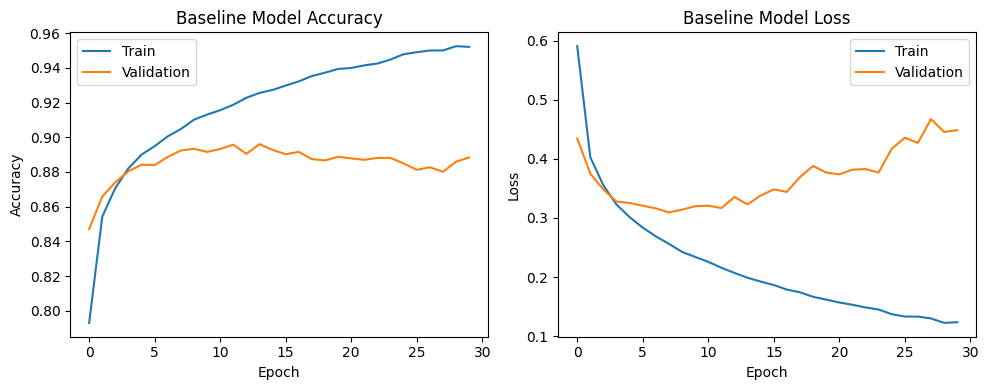

In [11]:
# Visualize baseline training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Train')
plt.plot(history_baseline.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Baseline Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Train')
plt.plot(history_baseline.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Model Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Add L2 Regularization *(10 points)*

L2 regularization (weight decay) penalizes large weights, encouraging simpler models.

Build a new model with the **same architecture** as the baseline, but add
`kernel_regularizer=l2(0.001)` to each Dense layer (except the output layer).

Store:
- **`model_l2`**: The L2-regularized model
- **`q5_l2_val_acc`**: Final validation accuracy after 30 epochs, rounded to 3 decimals

Model: "sequential_no_regularization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

layers
[<Dense name=dense_4, built=True>, <Dense name=dense_5, built=True>, <Dense name=dense_6, built=True>, <Dense name=dense_7, built=True>]
{'verbose': 0, 'epochs': 30, 'steps': 300}
q5_l2_val_acc: 0.879 | q5_l2_train_acc: 0.905


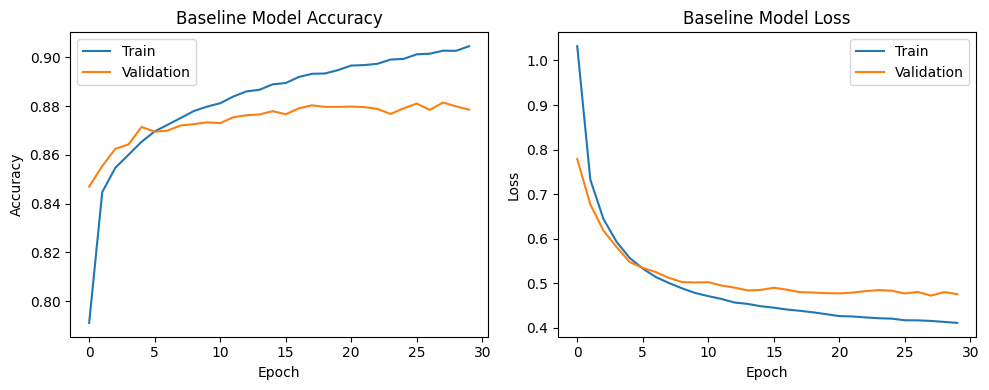

In [12]:
# your code here
# raise NotImplementedError

# ref
# https://keras.io/api/layers/regularizers/

# L2 Regularization (Weight Decay): Penalizes many weights
# from tensorflow.keras.regularizers import l2

# # Create a Sequential model
model_l2 = Sequential(name="sequential_no_regularization")

# Input & hidden layer 1
model_l2.add(Dense(256, input_shape=(n_features,), activation="relu", kernel_regularizer=l2(0.001)))

# # hidden layer 2
model_l2.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))

# # hidden layer 3
model_l2.add(Dense(64, activation="relu", kernel_regularizer=l2(0.001)))

# # output layer
model_l2.add(Dense(10, activation="softmax", kernel_regularizer=l2(0.001)))


# # total number of trainable parameters in q4_n_params (an integer).

# # Summarise your model
# # shows total params but 
model_l2.summary()

# Notes
# weights here actually seems to be a list of all weights and biases for all layers in order but 
# its not clear how to map to layers and their activations without using 
# layer.get_weights() which seems to be the only way to get the weights and biases per layer. 
# print(model.get_weights())

print('layers')
print(model_l2.layers)

    
model_l2.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# model fit & history
history_l2 = model_l2.fit(
    X_train, y_train,
    epochs=max_epochs, 
    batch_size=128, 
    verbose=0,
    validation_data=(X_val, y_val)
)

print(history_l2.params)


# q5_l2_val_acc: Final validation accuracy after 30 epochs, rounded to 3 decimals
q5_l2_train_acc = float(round(history_l2.history.get('accuracy')[last_epoch], 3))
q5_l2_val_acc = float(round(history_l2.history.get('val_accuracy')[last_epoch], 3))
print(f'q5_l2_val_acc: {q5_l2_val_acc} | q5_l2_train_acc: {q5_l2_train_acc}')


# Util
def visualize_history(h: tf.keras.callbacks.History):
    # Visualize baseline training curves
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h.history['accuracy'], label='Train')
    plt.plot(h.history['val_accuracy'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Baseline Model Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(h.history['loss'], label='Train')
    plt.plot(h.history['val_loss'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Baseline Model Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    
visualize_history(history_l2)


In [13]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert isinstance(model_l2, Sequential), (
    "model_l2 should be a Keras Sequential model."
)
assert isinstance(q5_l2_val_acc, float), (
    "q5_l2_val_acc must be a float."
)
assert 0 <= q5_l2_val_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
# Check that L2 regularization is applied
has_l2 = any(
    layer.kernel_regularizer is not None 
    for layer in model_l2.layers 
    if hasattr(layer, 'kernel_regularizer')
)
assert has_l2, (
    "Model should have L2 regularization. Use kernel_regularizer=l2(0.001)."
)
print(f"L2 Regularized model validation accuracy: {q5_l2_val_acc:.3f}")

L2 Regularized model validation accuracy: 0.879


## 6. Add Dropout *(10 points)*

Dropout randomly sets a fraction of activations to zero during training,
preventing co-adaptation of neurons.

Build a new model with the **same architecture**, but add `Dropout(0.3)` layers
after each hidden Dense layer (not after the output layer).

Store:
- **`model_dropout`**: The dropout model
- **`q6_dropout_val_acc`**: Final validation accuracy after 30 epochs, rounded to 3 decimals

Model: "sequential_with_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

layers
[<Dense name=dense_8, built=True>, <Dropout name=dropout, built=True>, <Dense name=dense_9, built=True>, <Dropout name=dropout_1, built=True>, <Dense name=dense_10, built=True>, <Dropout name=dropout_2, built=True>, <Dense name=dense_11, built=True>]
{'verbose': 0, 'epochs': 30, 'steps': 300}
q6_dropout_val_acc: 0.881 | q6_dropout_train_acc: 0.861


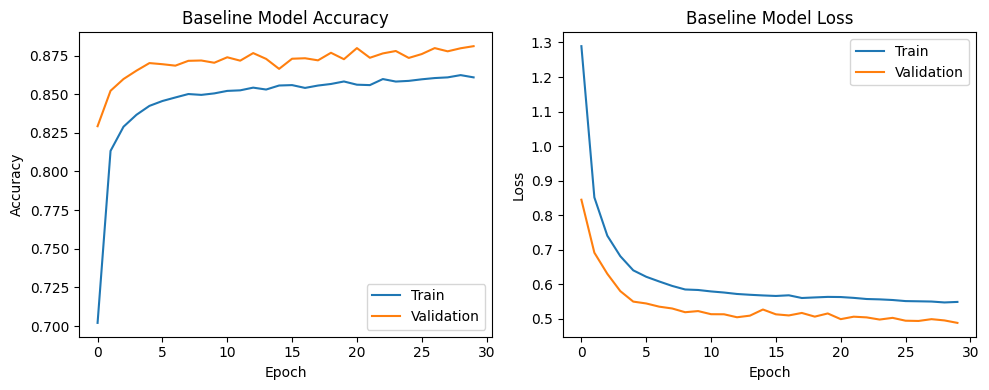

In [14]:
# your code here
# raise NotImplementedError


# # Create a Sequential model
model_dropout = Sequential(name="sequential_with_dropout")

# Input & hidden layer 1
model_dropout.add(Dense(256, input_shape=(n_features,), activation="relu", kernel_regularizer=l2(0.001)))

model_dropout.add(Dropout(0.3))

# # hidden layer 2
model_dropout.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))

model_dropout.add(Dropout(0.3))

# # hidden layer 3
model_dropout.add(Dense(64, activation="relu", kernel_regularizer=l2(0.001)))

model_dropout.add(Dropout(0.3))

# # output layer
model_dropout.add(Dense(10, activation="softmax", kernel_regularizer=l2(0.001)))


# # total number of trainable parameters in q4_n_params (an integer).

# # Summarise your model
# # shows total params but 
model_dropout.summary()

# Notes
# weights here actually seems to be a list of all weights and biases for all layers in order but 
# its not clear how to map to layers and their activations without using 
# layer.get_weights() which seems to be the only way to get the weights and biases per layer. 
# print(model.get_weights())

print('layers')
print(model_dropout.layers)

    
model_dropout.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# model fit & history
history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=max_epochs, 
    batch_size=128, 
    verbose=0,
    validation_data=(X_val, y_val)
)

print(history_dropout.params)

# q6_dropout_val_acc = float(round(history_dropout.history.get('accuracy')[last_epoch], 3))
# print(q6_dropout_val_acc)

q6_dropout_train_acc = float(round(history_dropout.history.get('accuracy')[last_epoch], 3))
q6_dropout_val_acc = float(round(history_dropout.history.get('val_accuracy')[last_epoch], 3))
print(f'q6_dropout_val_acc: {q6_dropout_val_acc} | q6_dropout_train_acc: {q6_dropout_train_acc}')

visualize_history(history_dropout)


In [15]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 6
assert isinstance(model_dropout, Sequential), (
    "model_dropout should be a Keras Sequential model."
)
assert isinstance(q6_dropout_val_acc, float), (
    "q6_dropout_val_acc must be a float."
)
assert 0 <= q6_dropout_val_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
# Check that Dropout layers are present
has_dropout = any(isinstance(layer, Dropout) for layer in model_dropout.layers)
assert has_dropout, (
    "Model should have Dropout layers. Add Dropout(0.3) after Dense layers."
)
print(f"Dropout model validation accuracy: {q6_dropout_val_acc:.3f}")

Dropout model validation accuracy: 0.881


## 7. Implement Early Stopping *(10 points)*

Early stopping monitors validation loss and stops training when it stops improving,
preventing overfitting by not training too long.

Build the **same baseline architecture** (no regularization) but train it with
an `EarlyStopping` callback:
- Monitor: `'val_loss'`
- Patience: `5` (wait 5 epochs before stopping)
- `restore_best_weights=True`

Train for a maximum of **100 epochs** (early stopping will likely stop sooner).

Store:
- **`model_early_stop`**: The model trained with early stopping
- **`q7_stopped_epoch`**: The epoch at which training stopped (integer)
- **`q7_early_val_acc`**: Final validation accuracy, rounded to 3 decimals

Model: "sequential_with_early_stopping"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

layers
[<Dense name=dense_24, built=True>, <Dropout name=dropout_9, built=True>, <Dense name=dense_25, built=True>, <Dropout name=dropout_10, built=True>, <Dense name=dense_26, built=True>, <Dropout name=dropout_11, built=True>, <Dense name=dense_27, built=True>]
{'verbose': 0, 'epochs': 100, 'steps': 300}
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
{'accuracy': [0.7000781297683716, 0.8152864575386047, 0.8373958468437195, 0.8472135663032532, 0.8544531464576721, 0.8597656488418579, 0.8642968535423279, 0.8679166436195374, 0.8712499737739563, 0.87479168176651, 0.8747656345367432, 0.8780729174613953, 0.8795312643051147, 0.8828385472297668, 0.887708306312561, 0.8868749737739563, 0.8867968916893005, 0.8901041746139526, 0.8918489813804626, 0.8945572972297668, 0.8945052027702332, 0.8942447900772095, 0.8949999809265137], 'loss': [0.8466393947601318, 0.5273484587669373, 0.46153178811073303, 0.4356100857257843, 0.4109968841075897, 0.3971133530139923, 0.382678747177124, 0.367827236

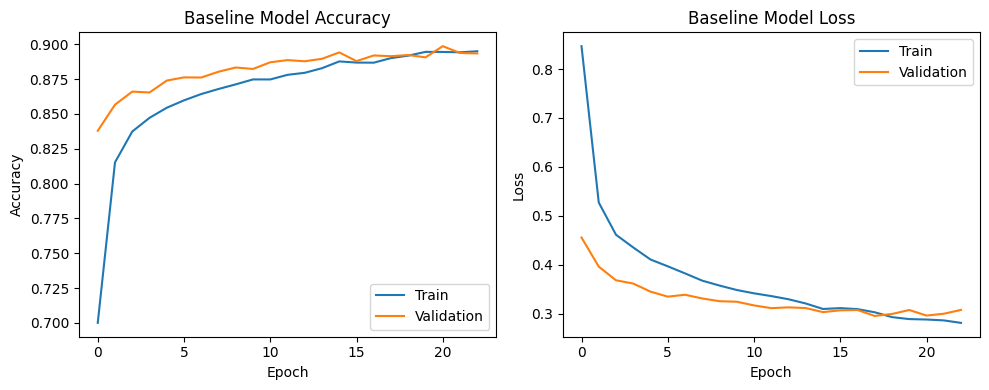

q7_early_val_acc: 0.893 | q7_early_train_acc: 0.895


In [39]:
# your code here
# raise NotImplementedError

# max_epochs_2 = 100
# last_epoch_2 = max_epochs_2-1

# ref:
# https://keras.io/api/callbacks/early_stopping/
# https://www.tensorflow.org/guide/keras/training_with_built_in_methods#using_callbacks

# callback = keras.callbacks.EarlyStopping(monitor='loss',
# ...                                               patience=3)
# >>> # This callback will stop the training when there is no improvement in
# >>> # the loss for three consecutive epochs.
# >>> model = keras.models.Sequential([keras.layers.Dense(10)])
# >>> model.compile(keras.optimizers.SGD(), loss='mse')
# >>> history = model.fit(np.arange(100).reshape(5, 20), np.zeros(5),
# ...                     epochs=10, batch_size=1, callbacks=[callback],
# ...                     verbose=0)
# >>> len(history.history['loss'])  # Only 4 epochs are run.
# 4

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]


# # Create a Sequential model
model_early_stop = Sequential(name="sequential_with_early_stopping")

# Input & hidden layer 1
model_early_stop.add(Dense(256, input_shape=(n_features,), activation="relu"))

model_early_stop.add(Dropout(0.3))

# # hidden layer 2
model_early_stop.add(Dense(128, activation="relu"))

model_early_stop.add(Dropout(0.3))

# # hidden layer 3
model_early_stop.add(Dense(64, activation="relu"))

model_early_stop.add(Dropout(0.3))

# # output layer
model_early_stop.add(Dense(10, activation="softmax"))


# # total number of trainable parameters in q4_n_params (an integer).

# # Summarise your model
# # shows total params but 
model_early_stop.summary()

# Notes
# weights here actually seems to be a list of all weights and biases for all layers in order but 
# its not clear how to map to layers and their activations without using 
# layer.get_weights() which seems to be the only way to get the weights and biases per layer. 
# print(model.get_weights())

print('layers')
print(model_early_stop.layers)

    
model_early_stop.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# model fit & history
history_early = model_early_stop.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=128, 
    verbose=0,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

print(history_early.params)
print(history_early.history.keys())
print(history_early.history)

# q6_dropout_val_acc = float(round(history_dropout.history.get('accuracy')[last_epoch_2], 3))
# print(q6_dropout_val_acc)

visualize_history(history_early)


# q7_stopped_epoch: The epoch at which training stopped (integer)
q7_stopped_epoch = len(history_early.history['loss'])  # Only n epochs are run.

# in 0 index range
last_stopped_epoch = q7_stopped_epoch-1

# q7_early_val_acc: Final validation accuracy, rounded to 3 decimals
# q7_early_val_acc = float(round(history_early_stop.history.get('accuracy')[last_stopped_epoch], 3))

q7_early_train_acc = float(round(history_early.history.get('accuracy')[last_stopped_epoch], 3))
q7_early_val_acc = float(round(history_early.history.get('val_accuracy')[last_stopped_epoch], 3))
print(f'q7_early_val_acc: {q7_early_val_acc} | q7_early_train_acc: {q7_early_train_acc}')


In [17]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert isinstance(model_early_stop, Sequential), (
    "model_early_stop should be a Keras Sequential model."
)
assert isinstance(q7_stopped_epoch, (int, np.integer)), (
    "q7_stopped_epoch must be an integer."
)
assert isinstance(q7_early_val_acc, float), (
    "q7_early_val_acc must be a float."
)
assert q7_stopped_epoch < 100, (
    "Early stopping should have stopped before 100 epochs. "
    "Check your EarlyStopping callback configuration."
)
assert q7_stopped_epoch > 5, (
    "Training stopped too early. Make sure patience=5."
)
print(f"Training stopped at epoch: {q7_stopped_epoch}")
print(f"Early stopping validation accuracy: {q7_early_val_acc:.3f}")

Training stopped at epoch: 37
Early stopping validation accuracy: 0.895


## 8. Add Batch Normalization *(10 points)*

Batch Normalization normalizes layer inputs, which stabilizes training and can
act as mild regularization.

Build a new model with BatchNormalization after each Dense layer (before activation):
- Dense(256) → BatchNormalization → ReLU (use `activation=None` in Dense, then separate layer)
- Or simpler: Dense(256, activation='relu') → BatchNormalization (after activation)

Use the simpler approach: add `BatchNormalization()` after each hidden Dense+ReLU layer.

Store:
- **`model_batchnorm`**: The batch-normalized model
- **`q8_batchnorm_val_acc`**: Final validation accuracy after 30 epochs, rounded to 3 decimals

Model: "sequential_with_batch_norm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

layers
[<Dense name=dense_16, built=True>, <BatchNormalization name=batch_normalization, built=True>, <Dense name=dense_17, built=True>, <BatchNormalization name=batch_normalization_1, built=True>, <Dense name=dense_18, built=True>, <BatchNormalization name=batch_normalization_2, built=True>, <Dense name=dense_19, built=True>]
{'verbose': 0, 'epochs': 30, 'steps': 300}
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
{'accuracy': [0.8295572996139526, 0.8664583563804626, 0.8790624737739563, 0.8899999856948853, 0.8961979150772095, 0.9002344012260437, 0.905078113079071, 0.9092447757720947, 0.9139322638511658, 0.9201562404632568, 0.9260416626930237, 0.9292187690734863, 0.93143230676651, 0.9330729246139526, 0.9386458396911621, 0.9435937404632568, 0.9453906416893005, 0.946484386920929, 0.9497656226158142, 0.95138019323349, 0.95333331823349, 0.9547916650772095, 0.9560156464576721, 0.9534114599227905, 0.959973931312561, 0.9635937213897705, 0.9655468463897705, 0.9667187333106995, 0.9

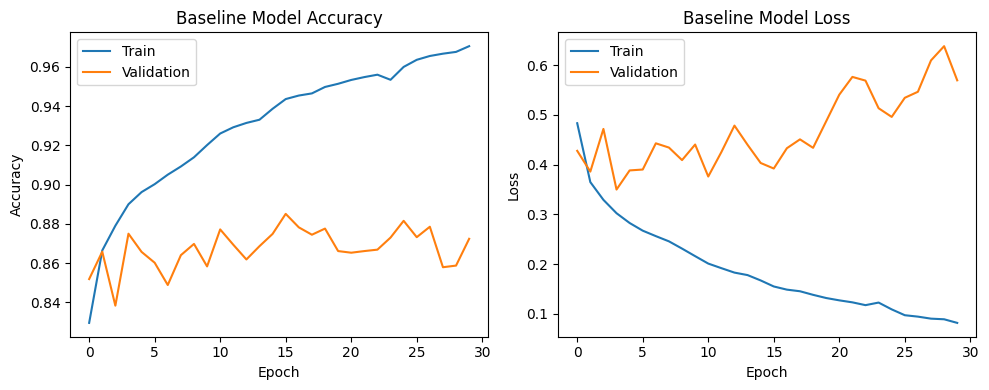

q8_batchnorm_val_acc: 0.872 | q8_batchnorm_train_acc: 0.971


In [18]:
# your code here
# raise NotImplementedError

from tensorflow.keras import layers

# ref
# https://keras.io/api/layers/normalization_layers/batch_normalization/
# 
# keras.layers.BatchNormalization(
#     axis=-1,
#     momentum=0.99,
#     epsilon=0.001,
#     center=True,
#     scale=True,
#     beta_initializer="zeros",
#     gamma_initializer="ones",
#     moving_mean_initializer="zeros",
#     moving_variance_initializer="ones",
#     beta_regularizer=None,
#     gamma_regularizer=None,
#     beta_constraint=None,
#     gamma_constraint=None,
#     synchronized=False,
#     **kwargs
# )

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]


# # Create a Sequential model
model_batchnorm = Sequential(name="sequential_with_batch_norm")

# Input & hidden layer 1
model_batchnorm.add(Dense(256, input_shape=(n_features,), activation='relu'))

model_batchnorm.add(BatchNormalization())

# # hidden layer 2
model_batchnorm.add(Dense(128, activation='relu'))

model_batchnorm.add(BatchNormalization())

# # hidden layer 3
model_batchnorm.add(Dense(64, activation=None))

model_batchnorm.add(BatchNormalization())

# # output layer
model_batchnorm.add(Dense(10, activation="softmax"))


# Build a new model with BatchNormalization after each Dense layer (before activation):

# Dense(256) → BatchNormalization → ReLU (use activation=None in Dense, then separate layer)
# Or simpler: Dense(256, activation='relu') → BatchNormalization (after activation)

# tried to craft another way but was not so sure of the layers

# model = Sequential([
#     layers.Dense(256),
#     layers.BatchNormalization(),      # Added before or after activation
#     layers.Dense(128, activation=None)
# #     layers.Activation('relu'),
#     layers.Dense(10, activation='softmax')
# ])

# # total number of trainable parameters in q4_n_params (an integer).

# # Summarise your model
# # shows total params but 
model_batchnorm.summary()

# Notes
# weights here actually seems to be a list of all weights and biases for all layers in order but 
# its not clear how to map to layers and their activations without using 
# layer.get_weights() which seems to be the only way to get the weights and biases per layer. 
# print(model.get_weights())

print('layers')
print(model_batchnorm.layers)

    
model_batchnorm.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# model fit & history
history_batchnorm = model_batchnorm.fit(
    X_train, y_train,
    epochs=max_epochs, 
    batch_size=128, 
    verbose=0,
    validation_data=(X_val, y_val),
#     callbacks=callbacks
)

print(history_batchnorm.params)
print(history_batchnorm.history.keys())
print(history_batchnorm.history)

visualize_history(history_batchnorm)


# q7_stopped_epoch: The epoch at which training stopped (integer)
# q7_stopped_epoch = len(history_batchnorm.history['loss'])  # Only n epochs are run.

# in 0 index range
last_stopped_epoch = q7_stopped_epoch-1

# q7_early_val_acc: Final validation accuracy, rounded to 3 decimals
# q8_batchnorm_val_acc = float(round(history_batchnorm.history.get('accuracy')[last_epoch], 3))

q8_batchnorm_train_acc = float(round(history_batchnorm.history.get('accuracy')[last_epoch], 3))
q8_batchnorm_val_acc = float(round(history_batchnorm.history.get('val_accuracy')[last_epoch], 3))
print(f'q8_batchnorm_val_acc: {q8_batchnorm_val_acc} | q8_batchnorm_train_acc: {q8_batchnorm_train_acc}')



In [19]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 8
assert isinstance(model_batchnorm, Sequential), (
    "model_batchnorm should be a Keras Sequential model."
)
assert isinstance(q8_batchnorm_val_acc, float), (
    "q8_batchnorm_val_acc must be a float."
)
assert 0 <= q8_batchnorm_val_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
# Check that BatchNormalization layers are present
has_batchnorm = any(isinstance(layer, BatchNormalization) for layer in model_batchnorm.layers)
assert has_batchnorm, (
    "Model should have BatchNormalization layers."
)
print(f"Batch Normalization model validation accuracy: {q8_batchnorm_val_acc:.3f}")

Batch Normalization model validation accuracy: 0.872


## 9. Compare All Models on Test Set *(10 points)*

Evaluate all five models on the **test set** and compare their performance.

Store a dictionary **`q9_test_accuracies`** with keys:
- `'baseline'`: Test accuracy of baseline model
- `'l2'`: Test accuracy of L2 regularized model
- `'dropout'`: Test accuracy of dropout model
- `'early_stopping'`: Test accuracy of early stopping model
- `'batchnorm'`: Test accuracy of batch normalization model

All values should be floats rounded to 3 decimals.

Also store **`q9_best_model`**: The key of the model with highest test accuracy.

In [20]:
# your code here
# raise NotImplementedError

# baseline_eval_metrics = model_baseline.evaluate(X_test, y_test, verbose=1, return_dict=True)
# print(baseline_eval_metrics)

q9_test_accuracies = {}

# model variable from earlier: final key name
models_mapping = {
#     'baseline': Test accuracy of baseline model
    'baseline': model_baseline,
#     'l2': Test accuracy of L2 regularized model
    'l2': model_l2,
#     'dropout': Test accuracy of dropout model
    'dropout': model_dropout,
#     'early_stopping': Test accuracy of early stopping model
    'early_stopping': model_early_stop,
#     'batchnorm': Test accuracy of batch normalization model
    'batchnorm': model_batchnorm
}

for i, (k, m) in enumerate(models_mapping.items()):
    eval_metrics = m.evaluate(X_test, y_test, verbose=1, return_dict=True)
    print(f'{k} : {m.name} -> {eval_metrics}')
#     All values should be floats rounded to 3 decimals.
    q9_test_accuracies[k] = float(round(eval_metrics.get('accuracy', None), 3))
    
display(q9_test_accuracies)


q9_test_accuracies_df = pd.DataFrame(q9_test_accuracies, index=[0])
display(q9_test_accuracies_df)
display(q9_test_accuracies_df.T)

# Also store q9_best_model: The key of the model with highest test accuracy.

# print(q9_test_accuracies_df.max())
# print('index on all columns')
# print(q9_test_accuracies_df.idxmax())
# print('on values -> ndarray')
# print(type(q9_test_accuracies_df.values))
# print(q9_test_accuracies_df.values)
# print(q9_test_accuracies_df.values.max())
print('on transpose -> Series: note selector column is int not str!')
# print(type(q9_test_accuracies_df.T[0]))
# print(q9_test_accuracies_df.T[0])
# print(type(q9_test_accuracies_df[:1]))
# print(q9_test_accuracies_df[:1])
print(q9_test_accuracies_df.T[0].max())
print(q9_test_accuracies_df.T[0].idxmax())

max_value = q9_test_accuracies_df.T[0].max()
max_value_index = q9_test_accuracies_df.T[0].idxmax()

q9_best_model = max_value_index



375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8838 - loss: 0.4782
baseline : sequential_no_regularization -> {'accuracy': 0.8837500214576721, 'loss': 0.4782032370567322}
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8759 - loss: 0.4943
l2 : sequential_no_regularization -> {'accuracy': 0.8759166598320007, 'loss': 0.494254469871521}
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8744 - loss: 0.5022
dropout : sequential_with_dropout -> {'accuracy': 0.8744166493415833, 'loss': 0.5022215247154236}
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8913 - loss: 0.3138
early_stopping : sequential_with_early_stopping -> {'accuracy': 0.8912500143051147, 'loss': 0.31381434202194214}
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8651 - loss: 0.6184
batchnorm : sequential_with_batch_norm -> {'accuracy': 0.8650833368301392, 'loss': 0.6184472441673279}


{'baseline': 0.884,
 'l2': 0.876,
 'dropout': 0.874,
 'early_stopping': 0.891,
 'batchnorm': 0.865}

,baseline,l2,dropout,early_stopping,batchnorm
0,0.884,0.876,0.874,0.891,0.865


,0
baseline,0.884
l2,0.876
dropout,0.874
early_stopping,0.891
batchnorm,0.865


on transpose -> Series: note selector column is int not str!
0.891
early_stopping


In [21]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 9
assert isinstance(q9_test_accuracies, dict), (
    "q9_test_accuracies must be a dictionary."
)
expected_keys = {'baseline', 'l2', 'dropout', 'early_stopping', 'batchnorm'}
assert set(q9_test_accuracies.keys()) == expected_keys, (
    f"Dictionary should have keys: {expected_keys}. Got: {set(q9_test_accuracies.keys())}"
)
for key, val in q9_test_accuracies.items():
    assert isinstance(val, float), f"Value for '{key}' must be a float."
    assert 0 <= val <= 1, f"Accuracy for '{key}' must be between 0 and 1."
assert isinstance(q9_best_model, str), (
    "q9_best_model must be a string (the model name)."
)
assert q9_best_model in expected_keys, (
    f"q9_best_model must be one of {expected_keys}."
)
print("Test Accuracies:")
for name, acc in q9_test_accuracies.items():
    print(f"  {name}: {acc:.3f}")
print(f"\nBest model: {q9_best_model}")

Test Accuracies:
  baseline: 0.884
  l2: 0.876
  dropout: 0.874
  early_stopping: 0.891
  batchnorm: 0.865

Best model: early_stopping


## 10. Analyze Overfitting Gap *(10 points)*

The **overfitting gap** is the difference between training accuracy and validation accuracy.
A large gap indicates the model is memorizing training data rather than learning general patterns.

For each model, compute the overfitting gap using the **final epoch's** accuracies:
`gap = train_accuracy - val_accuracy`

Store a dictionary **`q10_overfit_gaps`** with the same keys as above.
All values should be floats rounded to 3 decimals.

Also store **`q10_least_overfit`**: The key of the model with the **smallest** overfitting gap.

In [35]:
# your code here
# raise NotImplementedError


# Store a dictionary q10_overfit_gaps with the same keys as above. All values should be floats rounded to 3 decimals.
q10_overfit_gaps = {}

# model variable from earlier: final key name
train_val_mapping = {
#     'baseline': Test accuracy of baseline model
    'baseline': {
        'train': q4_final_train_acc,
        'val': q4_final_val_acc
    },
#     'l2': Test accuracy of L2 regularized model
    'l2': {
        'train': q5_l2_train_acc,
        'val': q5_l2_val_acc
    },
# #     'dropout': Test accuracy of dropout model
    'dropout': {
        'train': q6_dropout_train_acc,
        'val': q6_dropout_val_acc
    },
# #     'early_stopping': Test accuracy of early stopping model
    'early_stopping': {
        'train': q7_early_train_acc,
        'val': q7_early_val_acc
    },
# #     'batchnorm': Test accuracy of batch normalization model
    'batchnorm': {
        'train': q8_batchnorm_train_acc,
        'val': q8_batchnorm_val_acc
    }
}

for i, (m, v) in enumerate(train_val_mapping.items()):
    train_accuracy = v.get('train')
    val_accuracy = v.get('val')
    gap = train_accuracy - val_accuracy
    print(f'{m:<20} | train: {train_accuracy} | val: {train_accuracy} -> gap: {gap}')
#     All values should be floats rounded to 3 decimals.
    q10_overfit_gaps[m] = float(round(gap, 3))

display(q10_overfit_gaps)

q10_overfit_gaps_df = pd.DataFrame(q10_overfit_gaps, index=[0])

display(q10_overfit_gaps_df)
display(q10_overfit_gaps_df.T)
    
# Also store q10_least_overfit: The key of the model with the smallest overfitting gap.
print(q10_overfit_gaps_df.T[0].min())
print(q10_overfit_gaps_df.T[0].idxmin())
q10_least_overfit = q10_overfit_gaps_df.T[0].idxmin()


baseline             | train: 0.952 | val: 0.952 -> gap: 0.06399999999999995
l2                   | train: 0.905 | val: 0.905 -> gap: 0.026000000000000023
dropout              | train: 0.861 | val: 0.861 -> gap: -0.020000000000000018
early_stopping       | train: 0.904 | val: 0.904 -> gap: 0.009000000000000008
batchnorm            | train: 0.971 | val: 0.971 -> gap: 0.09899999999999998


{'baseline': 0.064,
 'l2': 0.026,
 'dropout': -0.02,
 'early_stopping': 0.009,
 'batchnorm': 0.099}

,baseline,l2,dropout,early_stopping,batchnorm
0,0.064,0.026,-0.02,0.009,0.099


,0
baseline,0.064
l2,0.026
dropout,-0.020
early_stopping,0.009
batchnorm,0.099


-0.02
dropout


In [36]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 10
assert isinstance(q10_overfit_gaps, dict), (
    "q10_overfit_gaps must be a dictionary."
)
expected_keys = {'baseline', 'l2', 'dropout', 'early_stopping', 'batchnorm'}
assert set(q10_overfit_gaps.keys()) == expected_keys, (
    f"Dictionary should have keys: {expected_keys}."
)
for key, val in q10_overfit_gaps.items():
    assert isinstance(val, float), f"Value for '{key}' must be a float."
assert isinstance(q10_least_overfit, str), (
    "q10_least_overfit must be a string (the model name)."
)
assert q10_least_overfit in expected_keys, (
    f"q10_least_overfit must be one of {expected_keys}."
)
print("Overfitting Gaps (Train Acc - Val Acc):")
for name, gap in q10_overfit_gaps.items():
    print(f"  {name}: {gap:.3f}")
print(f"\nLeast overfitting model: {q10_least_overfit}")

Overfitting Gaps (Train Acc - Val Acc):
  baseline: 0.064
  l2: 0.026
  dropout: -0.020
  early_stopping: 0.009
  batchnorm: 0.099

Least overfitting model: dropout


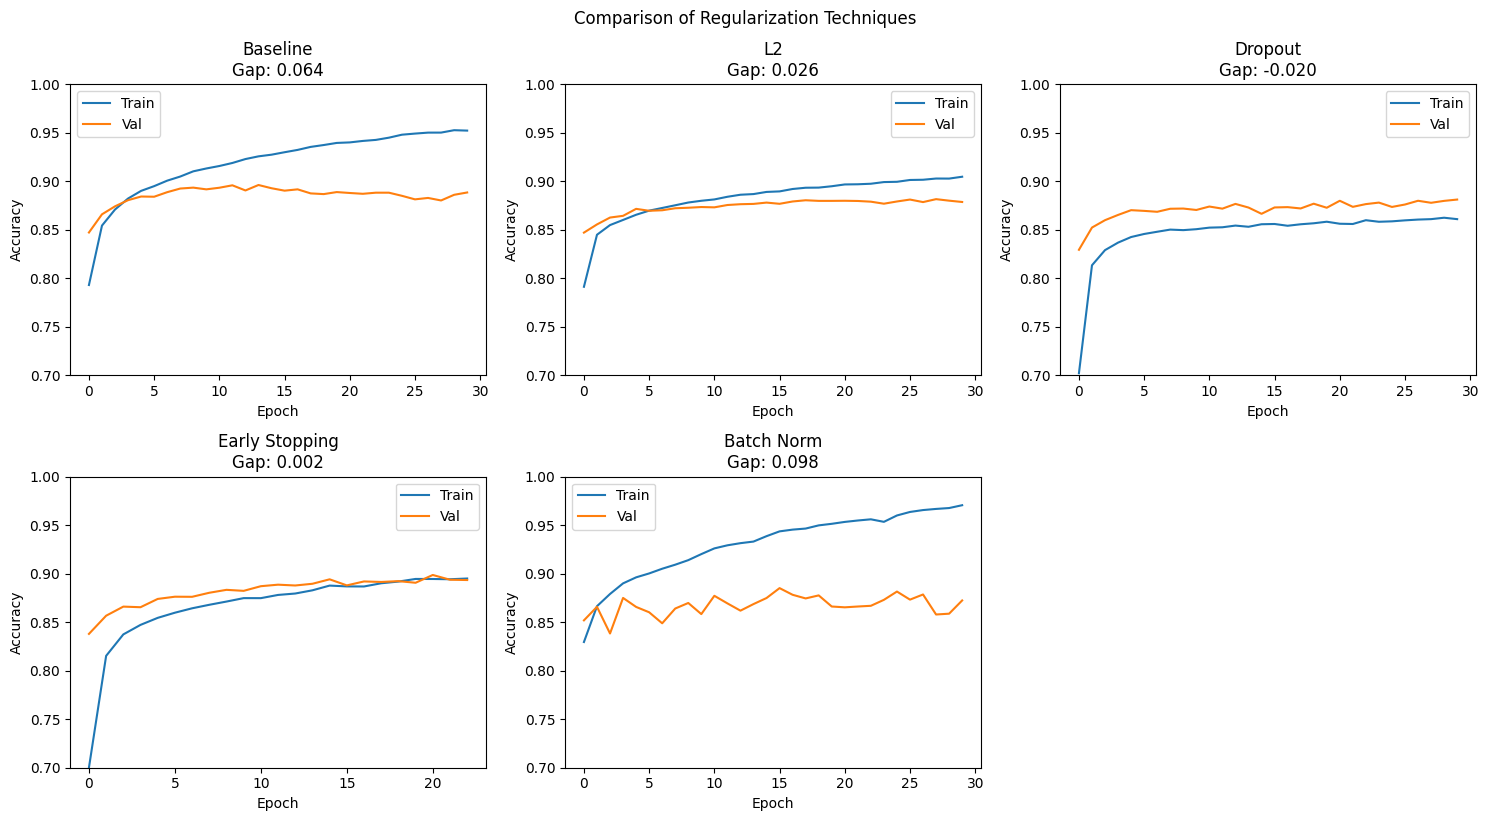

In [40]:
# Visualization: Compare all models
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

histories = {
    'Baseline': history_baseline,
    'L2': history_l2,
    'Dropout': history_dropout,
    'Early Stopping': history_early,
    'Batch Norm': history_batchnorm
}

for idx, (name, hist) in enumerate(histories.items()):
    ax = axes[idx // 3, idx % 3]
    ax.plot(hist.history['accuracy'], label='Train')
    ax.plot(hist.history['val_accuracy'], label='Val')
    ax.set_title(f'{name}\nGap: {hist.history["accuracy"][-1] - hist.history["val_accuracy"][-1]:.3f}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.set_ylim([0.7, 1.0])

# Hide the 6th subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.suptitle('Comparison of Regularization Techniques', y=1.02)
plt.show()

## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.
